## Regime change detection in financial time series


The goal of this project is to detect regime changes in a financial time series using a statistical model. Regime changes occur when the underlying behavior of a time series shifts, such as moving from a low-volatility period to a high-volatility period.

This project applies a regime-switching model to identify structural changes in the data and interpret how these changes impact financial decision-making.

The dataset selected for this analysis is the daily stock price data of Apple Inc. from January 1, 2018 to December 31, 2025, obtained using the yfinance API. This dataset was chosen because it contains a large number of observations and clearly exhibits periods of changing volatility and structural shifts, making it well-suited for regime change detection.

## Definition

The regime-switching model assumes that the observed time series is generated by different underlying states (regimes), each with its own statistical properties. The model can be written as:

$$
y_t = \mu_{S_t} + \varepsilon_t
$$

$$
\varepsilon_t \sim N(0, \sigma^2_{S_t})
$$

$$
P(S_t = j \mid S_{t-1} = i) = p_{ij}
$$

### Term definitions

- $y_t$: Observed value of the time series at time $t$ (e.g., daily returns of Apple stock)  
- $S_t$: Unobserved regime (state) at time $t$, where $S_t \in \{1, 2, ..., k\}$  
- $\mu_{S_t}$: Mean of the series in regime $S_t$  
- $\sigma^2_{S_t}$: Variance of the series in regime $S_t$, capturing volatility in that regime  
- $\varepsilon_t$: Error term at time $t$, assumed to be normally distributed  
- $p_{ij}$: Transition probability from regime $i$ at time $t-1$ to regime $j$ at time $t$  
- $P(S_t = j \mid S_{t-1} = i)$: Probability that the system switches regimes  

## Description

The regime-switching model identifies periods in a financial time series where behavior changes, such as shifts between low and high volatility. It does this by allowing the data to move between different hidden states, each with its own statistical characteristics.

## Demonstration

In [1]:
# Install package (only needed once in Colab)
!pip install yfinance

# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Download Apple Inc. data
data = yf.download("AAPL", start="2018-01-01", end="2025-12-31", auto_adjust=True)

# Reset index (makes Date a column instead of index)
data.reset_index(inplace=True)

# Display first rows
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Date,Close,High,Low,Open,Volume
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL
0,2018-01-02,40.304169,40.313530,39.602250,39.812828,102223600
1,2018-01-03,40.297176,40.839996,40.234006,40.367369,118071600
2,2018-01-04,40.484337,40.587286,40.262063,40.369689,89738400
3,2018-01-05,40.945263,41.031832,40.489016,40.580266,94640000
4,2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200


In [2]:
# Compute daily returns
data['Return'] = data['Close'].pct_change()

# Drop missing values
data = data.dropna()

data.head()

Price,Date,Close,High,Low,Open,Volume,Return
Ticker,,AAPL,AAPL,AAPL,AAPL,AAPL,
1,2018-01-03,40.297176,40.839996,40.234006,40.367369,118071600,-0.000173
2,2018-01-04,40.484337,40.587286,40.262063,40.369689,89738400,0.004645
3,2018-01-05,40.945263,41.031832,40.489016,40.580266,94640000,0.011385
4,2018-01-08,40.793182,41.087987,40.694911,40.793182,82271200,-0.003714
5,2018-01-09,40.788509,40.959309,40.573255,40.839984,86336000,-0.000115


## Apple stock price (2018–2025)

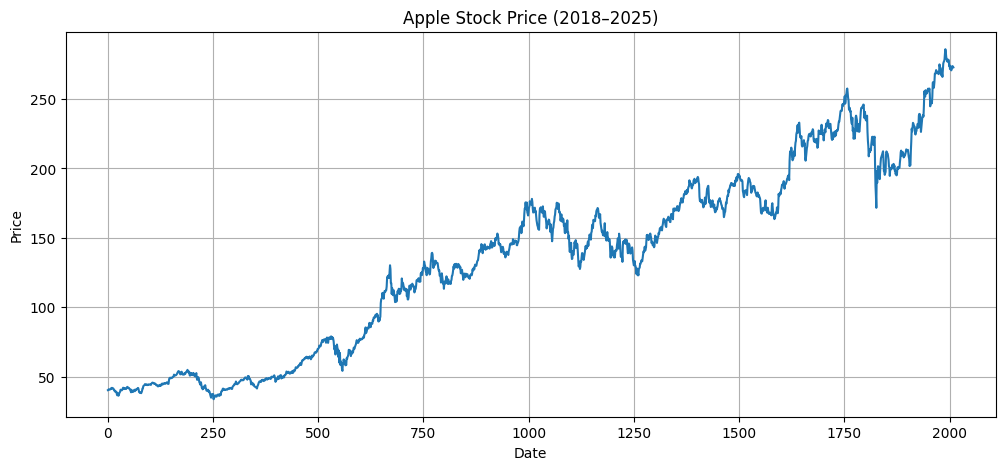

In [3]:
plt.figure(figsize=(12,5))
plt.plot(data['Close'])
plt.title("Apple Stock Price (2018–2025)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

## Apple daily returns

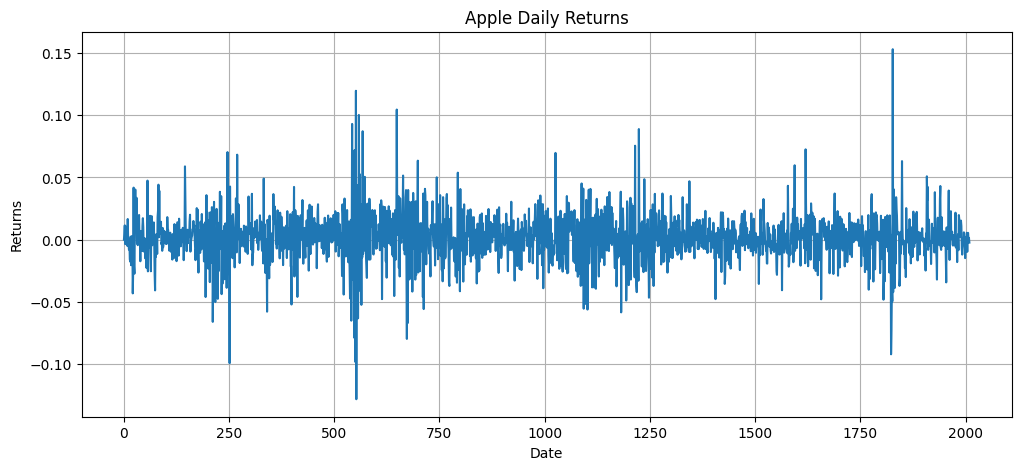

In [4]:
plt.figure(figsize=(12,5))
plt.plot(data['Return'])
plt.title("Apple Daily Returns")
plt.xlabel("Date")
plt.ylabel("Returns")
plt.grid()
plt.show()

## Interpretation of the charts

- The first plot shows the adjusted closing price of Apple Inc. from 2018 to 2025. The series exhibits a strong upward trend with noticeable periods of sharp declines and recoveries, indicating that the price process is non-stationary.

- The second plot shows the daily returns of Apple stock. Unlike the price series, returns fluctuate around a constant mean close to zero but display periods of clustering in volatility. These volatility clusters suggest that the variability of returns changes over time, which is a key indication of regime shifts in the data.

- Together, these patterns justify the use of a regime-switching model, as the financial time series does not behave consistently over the entire sample period but instead alternates between different volatility states.

In [5]:
import statsmodels.api as sm

# Fit Markov Switching Model (2 regimes)
model = sm.tsa.MarkovRegression(
    data['Return'],
    k_regimes=2,
    trend='c',
    switching_variance=True
)

results = model.fit()
# Calibration: Parameter Estimates
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


                        Markov Switching Model Results                        
Dep. Variable:                 Return   No. Observations:                 2009
Model:               MarkovRegression   Log Likelihood                5315.074
Date:                Fri, 08 May 2026   AIC                         -10618.147
Time:                        18:46:50   BIC                         -10584.515
Sample:                             0   HQIC                        -10605.801
                               - 2009                                         
Covariance Type:               approx                                         
                             Regime 0 parameters                              
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0017      0.000      4.674      0.000       0.001       0.002
sigma2         0.0001   9.24e-06     16.138      0.0

## Interpretation of model results

The Markov Switching model shows that Apple’s returns alternate between two regimes: a low-volatility (stable) state and a high-volatility (turbulent) state.

The low-volatility regime has small fluctuations and a positive mean return, indicating steady market conditions. In contrast, the high-volatility regime shows large fluctuations and no clear average return, reflecting periods of uncertainty.

The results also show that the stable regime is highly persistent, while high-volatility periods are usually short-lived and tend to return to stability.

Overall, this confirms that Apple’s returns do not behave consistently over time but switch between calm and volatile periods.

The variance parameters (σ²) measure volatility in each regime, while the transition probabilities capture the likelihood of staying in or switching between regimes over time.


##Diagram

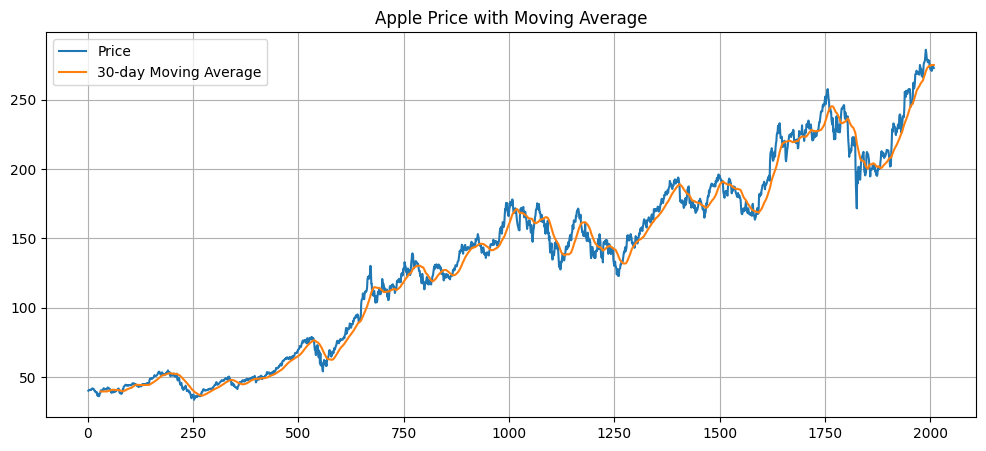

In [6]:
# Moving average (30 days)
data['MA30'] = data['Close'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(data['Close'], label='Price')
plt.plot(data['MA30'], label='30-day Moving Average')
plt.title("Apple Price with Moving Average")
plt.legend()
plt.grid()
plt.show()

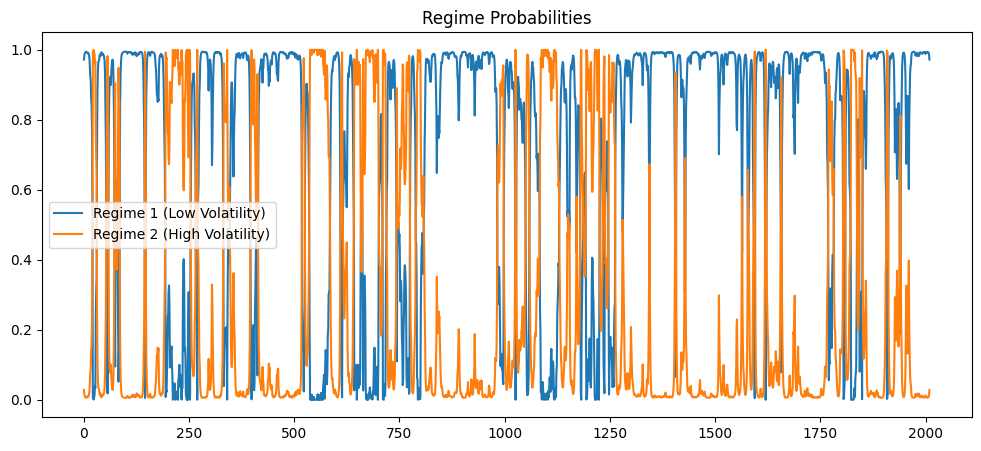

In [7]:
# Get smoothed probabilities
probs = results.smoothed_marginal_probabilities

# Plot regimes
plt.figure(figsize=(12,5))
plt.plot(probs[0], label='Regime 1 (Low Volatility)')
plt.plot(probs[1], label='Regime 2 (High Volatility)')
plt.title("Regime Probabilities")
plt.legend()
plt.show()

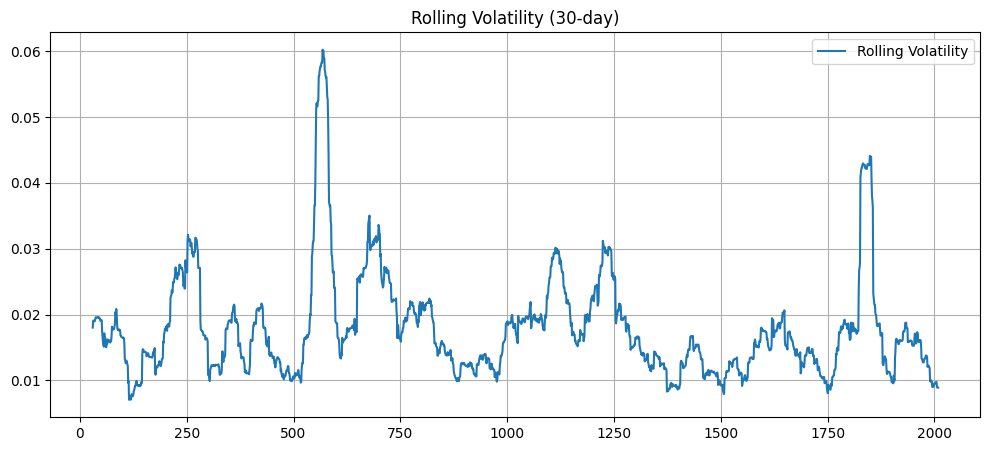

In [8]:
# Rolling volatility (30 days)
data['Rolling_Std'] = data['Return'].rolling(window=30).std()

plt.figure(figsize=(12,5))
plt.plot(data['Rolling_Std'], label='Rolling Volatility')
plt.title("Rolling Volatility (30-day)")
plt.legend()
plt.grid()
plt.show()

## Diagram Interpretation

The moving average smooths the price series and highlights the overall upward trend of Apple’s stock over time.

The rolling volatility plot shows that volatility is not constant, with clear periods of higher and lower fluctuations. This indicates changing market risk.

The regime probability plot shows switches between low and high volatility states. Periods of high volatility correspond to spikes in the rolling volatility, confirming that the model successfully captures changes in market conditions.


##Diagnosis

In [9]:
residuals = results.resid

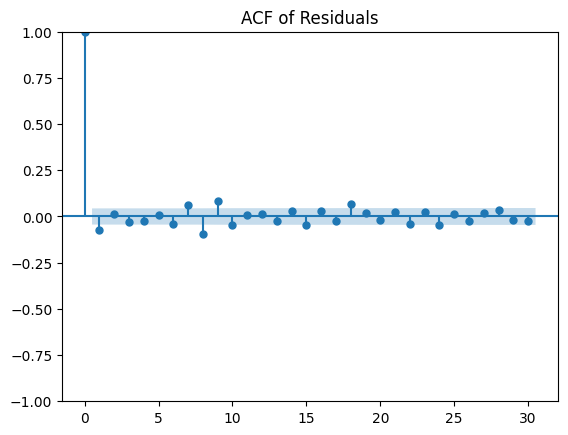

In [10]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(residuals, lags=30)
plt.title("ACF of Residuals")
plt.show()

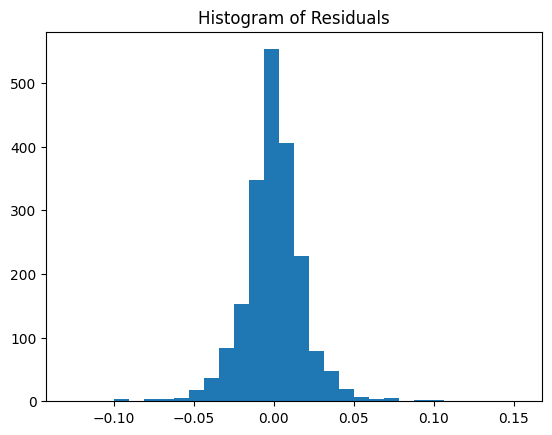

In [11]:
plt.hist(residuals, bins=30)
plt.title("Histogram of Residuals")
plt.show()

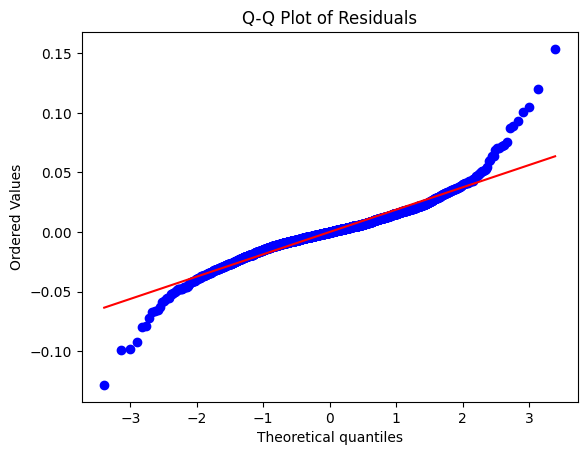

In [12]:
import scipy.stats as stats

stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of Residuals")
plt.show()

## Diagnostic interpretation

The autocorrelation (ACF) plot of the residuals shows that most of the autocorrelations lie within the confidence bounds, indicating little to no significant serial correlation. This suggests that the model has successfully captured the time dependence in the data.

The histogram of residuals appears approximately bell-shaped and centered around zero, indicating that the residuals are reasonably close to a normal distribution.

The Q–Q plot shows that most points lie along the straight line, although there are slight deviations in the tails. This suggests that while the residuals are broadly normal, there are some extreme values, which is common in financial data.

Overall, the diagnostic results indicate that the Markov Switching model provides a good fit to the data, with only minor deviations from the normality assumption.


## Model limitations (damage)

Although the Markov Switching model performs well, there are some limitations:

* The ACF plot suggests that most serial correlation has been captured, but there may still be small residual dependencies that the model does not fully explain.

* The regime probabilities show frequent switching between states, indicating that the separation between regimes is not always very sharp. This makes it harder to clearly distinguish between low and high volatility periods.

* The Q–Q plot shows slight deviations from normality in the tails, meaning extreme values are not perfectly captured. This is common in financial data where large shocks occur.

* The model may be slightly overfitted, as it uses multiple parameters to describe regime changes, which can reduce its ability to generalize.



## Directions for further analysis

To improve the model, a few steps could be taken:

* Remove or adjust extreme outliers to improve residual behavior.
* Change the data frequency (e.g., daily to weekly) to reduce noise.
* Add an extra regime to capture more complex market conditions.
* Adjust lag structure or include additional variables.




## Deployment

The model can be used to guide investment decisions by identifying low and high volatility periods.

* In low-volatility periods, investors may increase exposure to stocks.
* In high-volatility periods, they may reduce risk by shifting to safer assets.

The model can be updated daily or weekly, while considering transaction costs and using risk management strategies to limit losses.


## Conclusion

The Markov Switching model shows that Apple’s returns switch between low and high volatility periods, meaning market behavior changes over time.

Overall, the model captures these changes well and provides useful insights for understanding and managing financial risk.
